# Hybrid Deep Ensemble

## Table of Contents
* [Requirements](#requirements)
* [Respective Predictions](#respective-predictions)
    * [Respective Forecasts](#respective-forecasts)
    * [Respective Evaluations](#respective-evaluations)
* [Ensemble Predictions](#ensemble-predictions)
    * [Ensemble Forecasts](#ensemble-forecasts)
    * [Ensemble Evaluations](#ensemble-evaluations)

----

## Requirements

In [3]:
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import torch

sys.path.append('../../src')
from ann_models import create_sequences, GRU
from model_evaluation import cum_rmse, cum_mae, cum_nrmse, cum_rmae, cum_smape, cum_tic, cum_apb

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
sns.set_context('paper')

----

## Respective Predictions

### Respective Forecasts

In [4]:
imf = 1
device = torch.device('mps')

X_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_train_val.csv', index_col='datetime')
y_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_train_val.csv', index_col='datetime')
X_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_test.csv', index_col='datetime')
y_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_test.csv', index_col='datetime')

X_test = pd.concat([X_test, X_train.iloc[-24*7:]], axis=0).to_numpy()
y_test = pd.concat([y_test, y_train.iloc[-24*7:]], axis=0).to_numpy()

feature_scaler = StandardScaler()
feature_scaler.fit(X_train.to_numpy())
target_scaler = StandardScaler()
target_scaler.fit(y_train.to_numpy())

imf_gru_state_dict = torch.load(f'../../models/hde_respective_models/imf{imf}_gru_state_dict.pth', device)
IMF_GRU = GRU(input_size=X_train.shape[1]).to(device)
IMF_GRU.load_state_dict(imf_gru_state_dict)

X_test_scaled, y_test_scaled = feature_scaler.transform(X_test), target_scaler.transform(y_test)
X_test_scaled, y_test_scaled = create_sequences(X_test_scaled, y_test_scaled, seq_len=24*7, pred_len=24, stride=24)
X_test_scaled, y_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32, device=device), torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

IMF_GRU.eval()
with torch.no_grad():
    imf_y_test_pred_scaled = IMF_GRU.forward(X_test_scaled).cpu().detach().numpy().reshape(-1, 1)

imf1_y_test_pred = target_scaler.inverse_transform(imf_y_test_pred_scaled)
imf1_y_test = y_test[24*7:]

In [5]:
imf = 2
device = torch.device('mps')

X_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_train_val.csv', index_col='datetime')
y_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_train_val.csv', index_col='datetime')
X_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_test.csv', index_col='datetime')
y_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_test.csv', index_col='datetime')

X_test = pd.concat([X_test, X_train.iloc[-24*7:]], axis=0).to_numpy()
y_test = pd.concat([y_test, y_train.iloc[-24*7:]], axis=0).to_numpy()

feature_scaler = StandardScaler()
feature_scaler.fit(X_train.to_numpy())
target_scaler = StandardScaler()
target_scaler.fit(y_train.to_numpy())

imf_gru_state_dict = torch.load(f'../../models/hde_respective_models/imf{imf}_gru_state_dict.pth', device)
IMF_GRU = GRU(input_size=X_train.shape[1]).to(device)
IMF_GRU.load_state_dict(imf_gru_state_dict)

X_test_scaled, y_test_scaled = feature_scaler.transform(X_test), target_scaler.transform(y_test)
X_test_scaled, y_test_scaled = create_sequences(X_test_scaled, y_test_scaled, seq_len=24*7, pred_len=24, stride=24)
X_test_scaled, y_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32, device=device), torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

IMF_GRU.eval()
with torch.no_grad():
    imf_y_test_pred_scaled = IMF_GRU.forward(X_test_scaled).cpu().detach().numpy().reshape(-1, 1)

imf2_y_test_pred = target_scaler.inverse_transform(imf_y_test_pred_scaled)
imf2_y_test = y_test[24*7:]

In [6]:
imf = 3
device = torch.device('mps')

X_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_train_val.csv', index_col='datetime')
y_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_train_val.csv', index_col='datetime')
X_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_test.csv', index_col='datetime')
y_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_test.csv', index_col='datetime')

X_test = pd.concat([X_test, X_train.iloc[-24*7:]], axis=0).to_numpy()
y_test = pd.concat([y_test, y_train.iloc[-24*7:]], axis=0).to_numpy()

feature_scaler = StandardScaler()
feature_scaler.fit(X_train.to_numpy())
target_scaler = StandardScaler()
target_scaler.fit(y_train.to_numpy())

imf_gru_state_dict = torch.load(f'../../models/hde_respective_models/imf{imf}_gru_state_dict.pth', device)
IMF_GRU = GRU(input_size=X_train.shape[1]).to(device)
IMF_GRU.load_state_dict(imf_gru_state_dict)

X_test_scaled, y_test_scaled = feature_scaler.transform(X_test), target_scaler.transform(y_test)
X_test_scaled, y_test_scaled = create_sequences(X_test_scaled, y_test_scaled, seq_len=24*7, pred_len=24, stride=24)
X_test_scaled, y_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32, device=device), torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

IMF_GRU.eval()
with torch.no_grad():
    imf_y_test_pred_scaled = IMF_GRU.forward(X_test_scaled).cpu().detach().numpy().reshape(-1, 1)

imf3_y_test_pred = target_scaler.inverse_transform(imf_y_test_pred_scaled)
imf3_y_test = y_test[24*7:]

In [7]:
imf = 4
device = torch.device('mps')

X_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_train_val.csv', index_col='datetime')
y_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_train_val.csv', index_col='datetime')
X_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_test.csv', index_col='datetime')
y_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_test.csv', index_col='datetime')

X_test = pd.concat([X_test, X_train.iloc[-24*7:]], axis=0).to_numpy()
y_test = pd.concat([y_test, y_train.iloc[-24*7:]], axis=0).to_numpy()

feature_scaler = StandardScaler()
feature_scaler.fit(X_train.to_numpy())
target_scaler = StandardScaler()
target_scaler.fit(y_train.to_numpy())

imf_gru_state_dict = torch.load(f'../../models/hde_respective_models/imf{imf}_gru_state_dict.pth', device)
IMF_GRU = GRU(input_size=X_train.shape[1]).to(device)
IMF_GRU.load_state_dict(imf_gru_state_dict)

X_test_scaled, y_test_scaled = feature_scaler.transform(X_test), target_scaler.transform(y_test)
X_test_scaled, y_test_scaled = create_sequences(X_test_scaled, y_test_scaled, seq_len=24*7, pred_len=24, stride=24)
X_test_scaled, y_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32, device=device), torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

IMF_GRU.eval()
with torch.no_grad():
    imf_y_test_pred_scaled = IMF_GRU.forward(X_test_scaled).cpu().detach().numpy().reshape(-1, 1)

imf4_y_test_pred = target_scaler.inverse_transform(imf_y_test_pred_scaled)
imf4_y_test = y_test[24*7:]

In [8]:
imf = 5
device = torch.device('mps')

X_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_train_val.csv', index_col='datetime')
y_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_train_val.csv', index_col='datetime')
X_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_test.csv', index_col='datetime')
y_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_test.csv', index_col='datetime')

X_test = pd.concat([X_test, X_train.iloc[-24*7:]], axis=0).to_numpy()
y_test = pd.concat([y_test, y_train.iloc[-24*7:]], axis=0).to_numpy()

feature_scaler = StandardScaler()
feature_scaler.fit(X_train.to_numpy())
target_scaler = StandardScaler()
target_scaler.fit(y_train.to_numpy())

imf_gru_state_dict = torch.load(f'../../models/hde_respective_models/imf{imf}_gru_state_dict.pth', device)
IMF_GRU = GRU(input_size=X_train.shape[1]).to(device)
IMF_GRU.load_state_dict(imf_gru_state_dict)

X_test_scaled, y_test_scaled = feature_scaler.transform(X_test), target_scaler.transform(y_test)
X_test_scaled, y_test_scaled = create_sequences(X_test_scaled, y_test_scaled, seq_len=24*7, pred_len=24, stride=24)
X_test_scaled, y_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32, device=device), torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

IMF_GRU.eval()
with torch.no_grad():
    imf_y_test_pred_scaled = IMF_GRU.forward(X_test_scaled).cpu().detach().numpy().reshape(-1, 1)

imf5_y_test_pred = target_scaler.inverse_transform(imf_y_test_pred_scaled)
imf5_y_test = y_test[24*7:]

In [9]:
imf = 6
device = torch.device('mps')

X_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_train_val.csv', index_col='datetime')
y_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_train_val.csv', index_col='datetime')
X_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_test.csv', index_col='datetime')
y_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_test.csv', index_col='datetime')

X_test = pd.concat([X_test, X_train.iloc[-24*7:]], axis=0).to_numpy()
y_test = pd.concat([y_test, y_train.iloc[-24*7:]], axis=0).to_numpy()

feature_scaler = StandardScaler()
feature_scaler.fit(X_train.to_numpy())
target_scaler = StandardScaler()
target_scaler.fit(y_train.to_numpy())

imf_gru_state_dict = torch.load(f'../../models/hde_respective_models/imf{imf}_gru_state_dict.pth', device)
IMF_GRU = GRU(input_size=X_train.shape[1]).to(device)
IMF_GRU.load_state_dict(imf_gru_state_dict)

X_test_scaled, y_test_scaled = feature_scaler.transform(X_test), target_scaler.transform(y_test)
X_test_scaled, y_test_scaled = create_sequences(X_test_scaled, y_test_scaled, seq_len=24*7, pred_len=24, stride=24)
X_test_scaled, y_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32, device=device), torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

IMF_GRU.eval()
with torch.no_grad():
    imf_y_test_pred_scaled = IMF_GRU.forward(X_test_scaled).cpu().detach().numpy().reshape(-1, 1)

imf6_y_test_pred = target_scaler.inverse_transform(imf_y_test_pred_scaled)
imf6_y_test = y_test[24*7:]

In [10]:
imf = 7
device = torch.device('mps')

X_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_train_val.csv', index_col='datetime')
y_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_train_val.csv', index_col='datetime')
X_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_test.csv', index_col='datetime')
y_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_test.csv', index_col='datetime')

X_test = pd.concat([X_test, X_train.iloc[-24*7:]], axis=0).to_numpy()
y_test = pd.concat([y_test, y_train.iloc[-24*7:]], axis=0).to_numpy()

feature_scaler = StandardScaler()
feature_scaler.fit(X_train.to_numpy())
target_scaler = StandardScaler()
target_scaler.fit(y_train.to_numpy())

imf_gru_state_dict = torch.load(f'../../models/hde_respective_models/imf{imf}_gru_state_dict.pth', device)
IMF_GRU = GRU(input_size=X_train.shape[1]).to(device)
IMF_GRU.load_state_dict(imf_gru_state_dict)

X_test_scaled, y_test_scaled = feature_scaler.transform(X_test), target_scaler.transform(y_test)
X_test_scaled, y_test_scaled = create_sequences(X_test_scaled, y_test_scaled, seq_len=24*7, pred_len=24, stride=24)
X_test_scaled, y_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32, device=device), torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

IMF_GRU.eval()
with torch.no_grad():
    imf_y_test_pred_scaled = IMF_GRU.forward(X_test_scaled).cpu().detach().numpy().reshape(-1, 1)

imf7_y_test_pred = target_scaler.inverse_transform(imf_y_test_pred_scaled)
imf7_y_test = y_test[24*7:]

In [11]:
imf = 8
device = torch.device('mps')

X_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_train_val.csv', index_col='datetime')
y_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_train_val.csv', index_col='datetime')
X_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_test.csv', index_col='datetime')
y_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_test.csv', index_col='datetime')

X_test = pd.concat([X_test, X_train.iloc[-24*7:]], axis=0).to_numpy()
y_test = pd.concat([y_test, y_train.iloc[-24*7:]], axis=0).to_numpy()

feature_scaler = StandardScaler()
feature_scaler.fit(X_train.to_numpy())
target_scaler = StandardScaler()
target_scaler.fit(y_train.to_numpy())

imf_gru_state_dict = torch.load(f'../../models/hde_respective_models/imf{imf}_gru_state_dict.pth', device)
IMF_GRU = GRU(input_size=X_train.shape[1]).to(device)
IMF_GRU.load_state_dict(imf_gru_state_dict)

X_test_scaled, y_test_scaled = feature_scaler.transform(X_test), target_scaler.transform(y_test)
X_test_scaled, y_test_scaled = create_sequences(X_test_scaled, y_test_scaled, seq_len=24*7, pred_len=24, stride=24)
X_test_scaled, y_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32, device=device), torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

IMF_GRU.eval()
with torch.no_grad():
    imf_y_test_pred_scaled = IMF_GRU.forward(X_test_scaled).cpu().detach().numpy().reshape(-1, 1)

imf8_y_test_pred = target_scaler.inverse_transform(imf_y_test_pred_scaled)
imf8_y_test = y_test[24*7:]

In [12]:
imf = 9
device = torch.device('mps')

X_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_train_val.csv', index_col='datetime')
y_train = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_train_val.csv', index_col='datetime')
X_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_x_test.csv', index_col='datetime')
y_test = pd.read_csv(f'../../data/processed/imf{imf}/imf{imf}_y_test.csv', index_col='datetime')

test_datetime = pd.to_datetime(X_test.index, utc=True).to_numpy()

X_test = pd.concat([X_test, X_train.iloc[-24*7:]], axis=0).to_numpy()
y_test = pd.concat([y_test, y_train.iloc[-24*7:]], axis=0).to_numpy()

feature_scaler = StandardScaler()
feature_scaler.fit(X_train.to_numpy())
target_scaler = StandardScaler()
target_scaler.fit(y_train.to_numpy())

imf_gru_state_dict = torch.load(f'../../models/hde_respective_models/imf{imf}_gru_state_dict.pth', device)
IMF_GRU = GRU(input_size=X_train.shape[1]).to(device)
IMF_GRU.load_state_dict(imf_gru_state_dict)

X_test_scaled, y_test_scaled = feature_scaler.transform(X_test), target_scaler.transform(y_test)
X_test_scaled, y_test_scaled = create_sequences(X_test_scaled, y_test_scaled, seq_len=24*7, pred_len=24, stride=24)
X_test_scaled, y_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32, device=device), torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

IMF_GRU.eval()
with torch.no_grad():
    imf_y_test_pred_scaled = IMF_GRU.forward(X_test_scaled).cpu().detach().numpy().reshape(-1, 1)

imf9_y_test_pred = target_scaler.inverse_transform(imf_y_test_pred_scaled)
imf9_y_test = y_test[24*7:]

In [13]:
IMF_GRU.forward(X_test_scaled).cpu().detach().numpy().reshape(-1, 1).shape

(1752, 1)

### Respective Evaluations

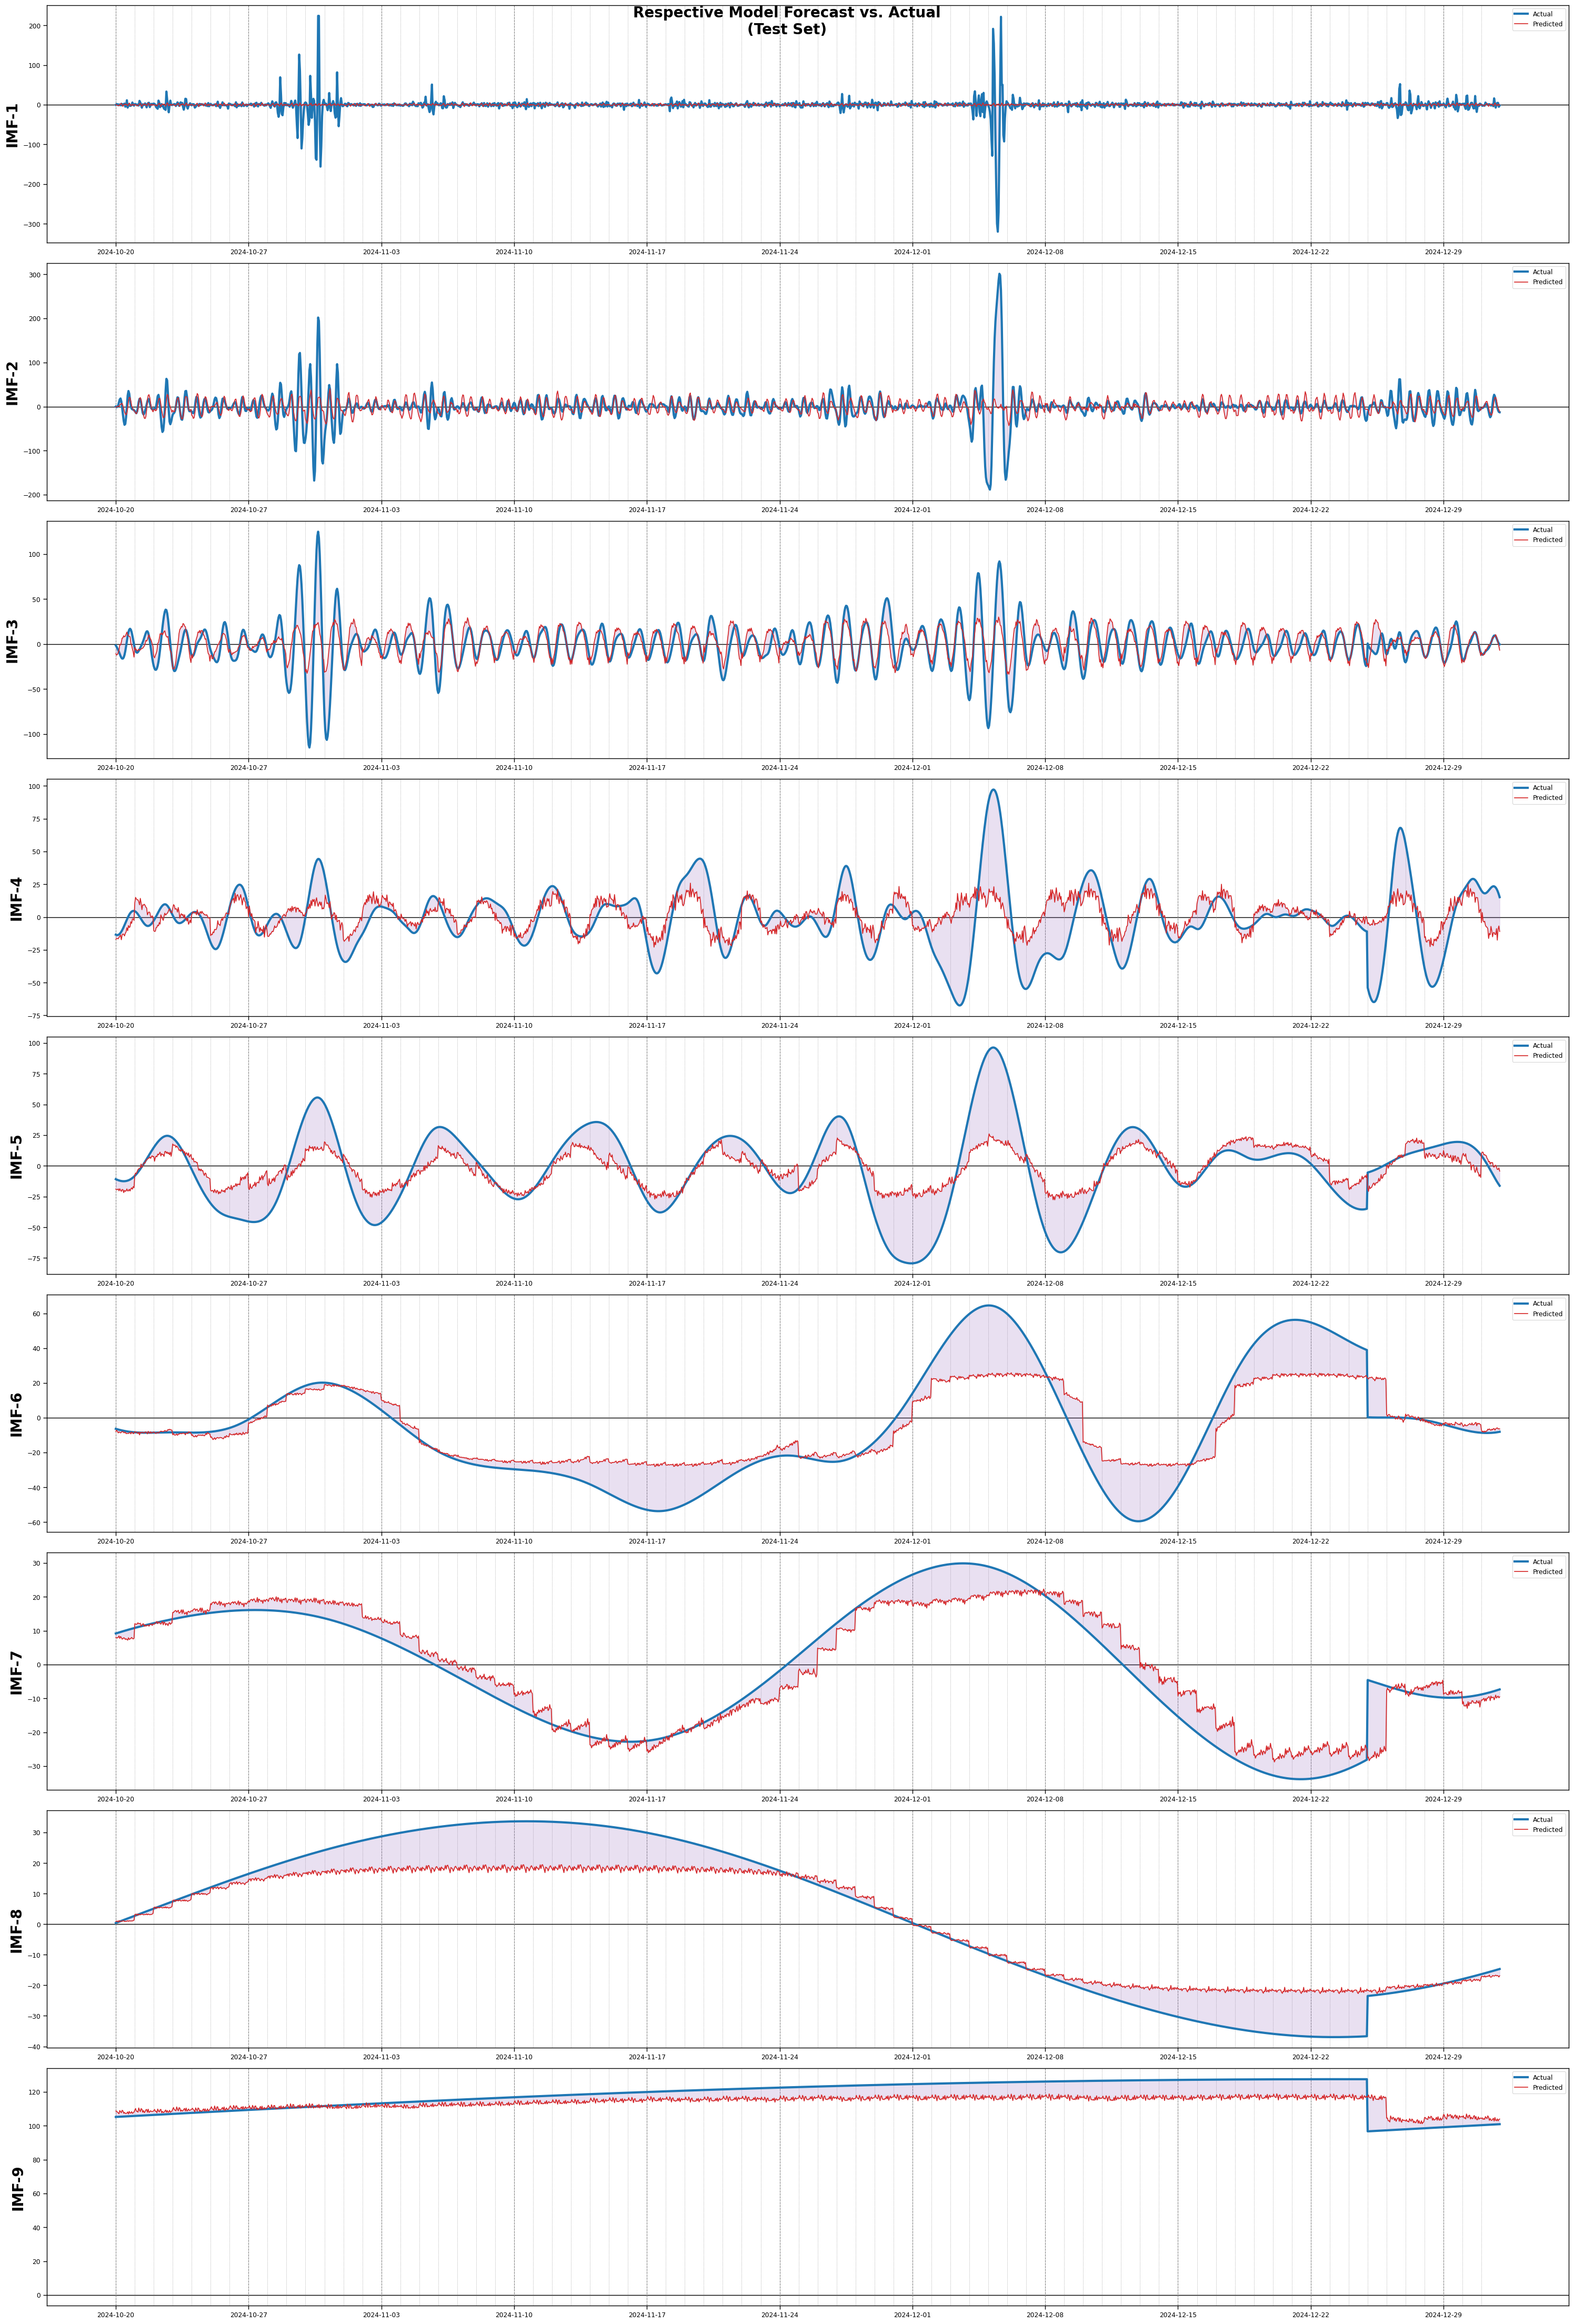

In [14]:
imf_trues = [imf1_y_test, imf2_y_test, imf3_y_test, imf4_y_test, imf5_y_test, imf6_y_test, imf7_y_test, imf8_y_test, imf9_y_test]
imf_preds = [imf1_y_test_pred, imf2_y_test_pred, imf3_y_test_pred, imf4_y_test_pred, imf5_y_test_pred, imf6_y_test_pred, imf7_y_test_pred, imf8_y_test_pred, imf9_y_test_pred]

fig, axes = plt.subplots(nrows=9, ncols=1, figsize=(30, 45))

for imf, (ax, (y_true, y_pred)) in enumerate(zip(axes, zip(imf_trues, imf_preds))):
    ax.axhline(0, color='black', linewidth=1, zorder=0)

    ax.plot(test_datetime, y_true, color='tab:blue', linewidth=3, zorder=3, label='Actual')
    ax.plot(test_datetime, y_pred, color='tab:red', zorder=4, label='Predicted')
    ax.fill_between(test_datetime, y_true.flatten(), y_pred.flatten(), color='tab:purple', alpha=0.2, zorder=2)

    for hour in test_datetime[[dt.hour == 0 for dt in test_datetime]]:
        ax.axvline(hour, color='gray', linestyle=':', linewidth=0.5, zorder=1)

    week_ticks = [dt for dt in test_datetime if (dt.weekday() == 6 and dt.hour == 0)]
    for week in week_ticks:
        ax.axvline(week, color='gray', linestyle='--', linewidth=0.75, zorder=1)
    ax.set_xticks(week_ticks)
    ax.set_xticklabels([dt.strftime('%Y-%m-%d') for dt in week_ticks])

    ax.set_ylabel(f'IMF-{imf+1}', fontsize=20, fontweight='bold')
    ax.legend()

fig.suptitle('Respective Model Forecast vs. Actual\n(Test Set)', fontsize=20, fontweight='bold')
fig.tight_layout()
fig.savefig('../../results/hybrid_deep_ensemble/hde_respective_forecasts.png', dpi=1000)
plt.show()

----

## Ensemble Predictions

### Ensemble Forecasts

In [15]:
y_test = np.zeros_like(imf1_y_test)
for imf_y_test in imf_trues:
    y_test += imf_y_test

y_test_pred = np.zeros_like(imf1_y_test_pred)
for imf_y_test_pred in imf_preds:
    y_test_pred += imf_y_test_pred

### Ensemble Evaluations

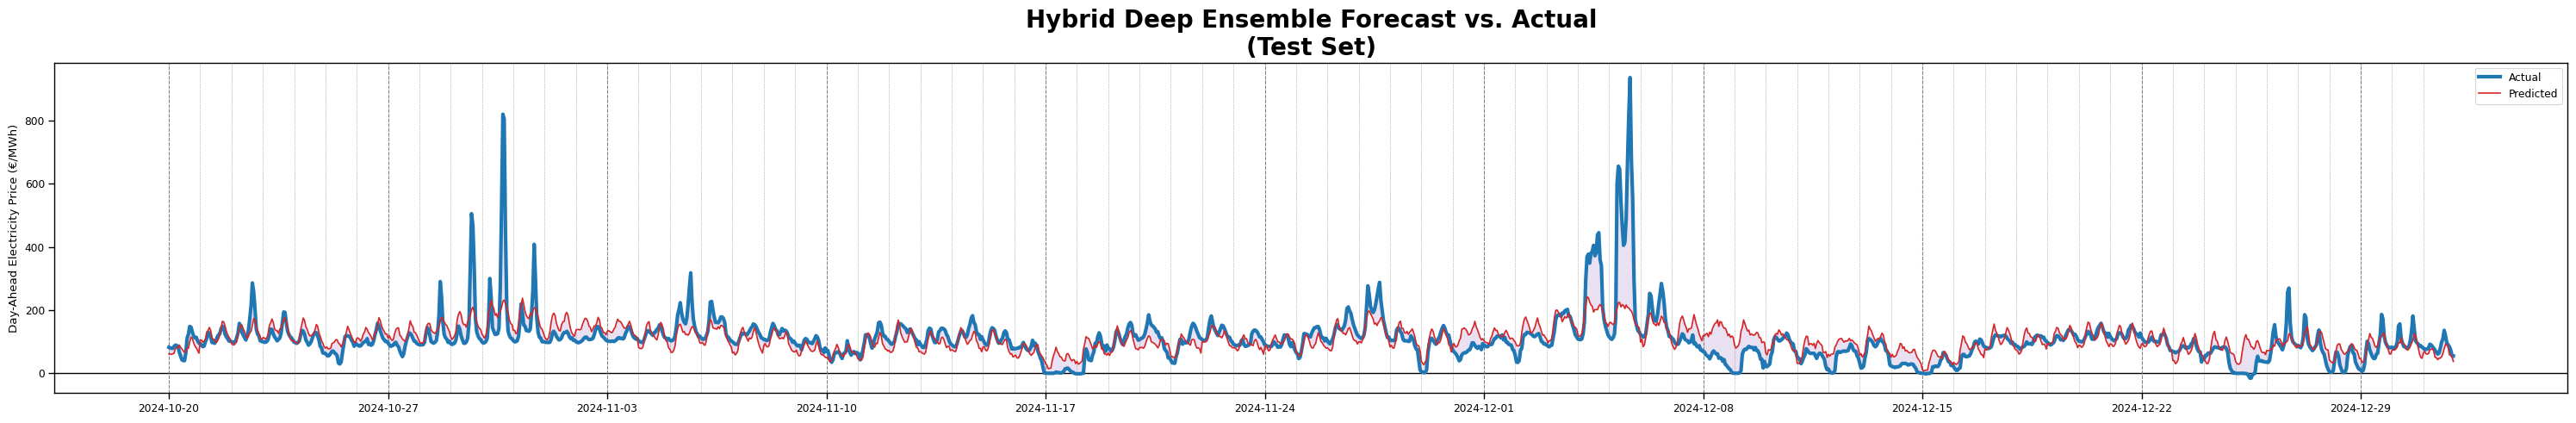

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(30, 5))

ax.axhline(0, color='black', linewidth=1, zorder=0)

ax.plot(test_datetime, y_test, color='tab:blue', linewidth=3, zorder=3, label='Actual')
ax.plot(test_datetime, y_test_pred, color='tab:red', zorder=4, label='Predicted')
ax.fill_between(test_datetime, y_test.flatten(), y_test_pred.flatten(), color='tab:purple', alpha=0.2, zorder=2)

for hour in test_datetime[[dt.hour == 0 for dt in test_datetime]]:
    ax.axvline(hour, color='gray', linestyle=':', linewidth=0.5, zorder=1)

week_ticks = [dt for dt in test_datetime if (dt.weekday() == 6 and dt.hour == 0)]
for week in week_ticks:
    ax.axvline(week, color='gray', linestyle='--', linewidth=0.75, zorder=1)
ax.set_xticks(week_ticks)
ax.set_xticklabels([dt.strftime('%Y-%m-%d') for dt in week_ticks])

ax.set_ylabel('Day-Ahead Electricity Price (€/MWh)')
ax.set_title('Hybrid Deep Ensemble Forecast vs. Actual\n(Test Set)', fontsize=20, fontweight='bold')
ax.legend()

fig.tight_layout()
fig.savefig('../../results/hybrid_deep_ensemble/hde_forecast.png', dpi=1000)
plt.show()

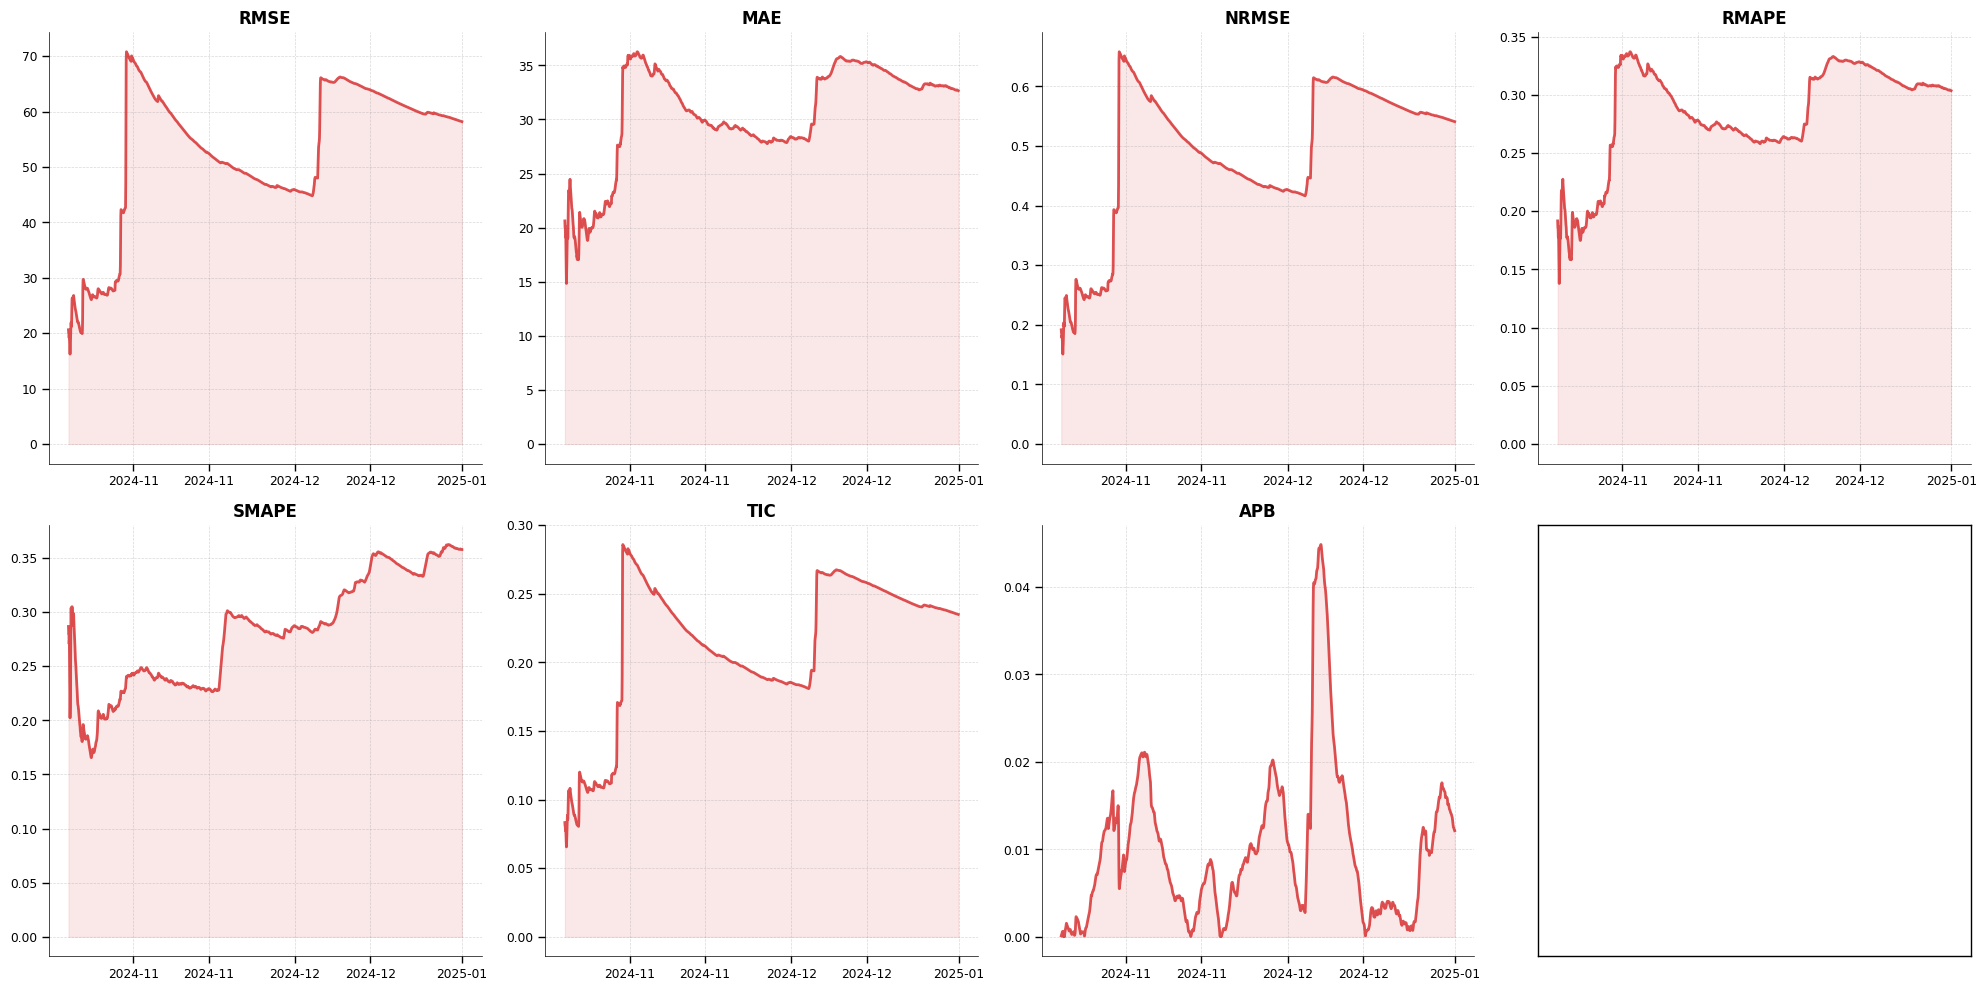

In [17]:
metric_strs = ['rmse', 'mae', 'nrmse', 'rmape', 'smape', 'tic', 'apb']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

ax_ct = 0
for i, (metric, metric_str) in enumerate(zip([cum_rmse, cum_mae, cum_nrmse, cum_rmae, cum_smape, cum_tic, cum_apb], metric_strs)):
    ax = axes[i]
    expanding_score = metric(y_true=y_test, y_pred=y_test_pred)
    ax.plot(test_datetime, expanding_score, color='tab:red', linewidth=2, alpha=0.8, zorder=2)
    ax.fill_between(test_datetime, expanding_score, color='tab:red', alpha=0.1, zorder=1)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.grid(which='major', linestyle='--', linewidth=0.5, alpha=0.3, color='gray')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    ax.set_title(metric_str.upper(), fontweight='bold', fontsize=12)
    plt.setp(ax.xaxis.get_majorticklabels(), ha='center')

legend_ax = axes[-1]
legend_ax.clear()

legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.set_frame_on(True)
for spine in legend_ax.spines.values():
    spine.set_visible(True)

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='center', frameon=False, fontsize=18, markerscale=2, bbox_to_anchor=(0.5, 0.5), bbox_transform=legend_ax.transAxes)

fig.tight_layout()
fig.savefig('../../results/hybrid_deep_ensemble/hde_bias_evaluation.png', dpi=1000)
plt.show()